In [8]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths
from typing import Callable

from pathlib import Path

from numpy.typing import NDArray
import numpy as np
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask, count
from bloodmoon.images import argmax

import darksun as ds

ds.show.set_figures_darkbkg()

In [9]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_infdet_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"

UPS_X: int = 10
UPS_Y: int = 5

In [10]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)


# data from camera A
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
#sdlA_detct = ds.get_data(filepaths[ID_CAMERA_A]['detected'])
sdlA_recnstr = ds.get_data(filepaths[ID_CAMERA_A]['reconstructed'])

## data from camera B
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
#sdlB_detct = ds.get_data(filepaths[ID_CAMERA_B]['detected'])
sdlB_recnstr = ds.get_data(filepaths[ID_CAMERA_B]['reconstructed'])

In [11]:
from bloodmoon.types import CoordEquatorial
from darksun.benchmarking import source_catalogue_data
from darksun.data import DataLoader, CatalogueLoader

type EnergyRange = tuple[float, float]


def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def filter_energy(
    photons: FITS_rec,
    E_min: float | None,
    E_max: float | None,
) -> FITS_rec:
    """Filters the input photons by energy, in [keV]."""
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)

## Kernel Fit - Fixed ModSech Exponent

- Let's fit the detector spatial resolution kernel parameters by applying the instr. effect to the source shadowgram model

- Here the goal is to obtain the kernel parameters by convolving the source model (only vignetted) with the PSFY kernel and minimising the MSE between convolved model and reconstructed detector images

- **NOTE**: In this NoteBook, the PSFY kernel is fitted by fixing the parameter $\beta$ (exponent inside the `modsech` argument)

In [12]:
from dataclasses import dataclass
from functools import partial

from scipy.optimize import curve_fit
from scipy.signal import convolve

from bloodmoon.images import fshift
from bloodmoon.mask import decode
from bloodmoon.optim import _detector_footprint_cached, apply_vignetting


@dataclass
class OptParams:
    """Optimisation results."""
    params: NDArray
    covar: NDArray

def project_mask_pattern(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
) -> NDArray:
    """Projects the camera mask pattern on the detector plane."""
    pxdimy, pxdimx = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    fr, fc = (
        (-1.0) * shift_y / pxdimy,
        (-1.0) * shift_x / pxdimx,
    )
    mask_shifted = fshift(camera.mask.astype(float), fr, fc)
    mask_vignetted = apply_vignetting(camera, mask_shifted, shift_x, shift_y)
    return mask_vignetted

def extract_detector(
    camera: CodedMaskCamera,
    mask_projection: NDArray,
) -> NDArray:
    """
    Extracts the detector image from the mask pattern projection on the detector plane.
    """
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = mask_projection[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    detector /= np.sum(detector)
    return detector


def compute_psfy_kernel(x: NDArray, alpha: float, beta: float = 0.85) -> NDArray:
    """Computes the LEM-X detector spatial resolution kernel from input params."""
    modsec = 1.0 / np.cosh(np.abs(x / alpha) ** beta)
    psfy = modsec.reshape(len(x), -1)
    return psfy / np.sum(psfy)

def apply_detector_resolution(shadowgram: NDArray, kernel: NDArray) -> NDArray:
    """Applies finite detector spatial resolution effects to a shadowgram."""
    return convolve(shadowgram, kernel, mode="same")


def config_KernelFitFunc(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    cts: float,
) -> Callable[[NDArray, float, float], NDArray]:
    """Initialises the kernel model."""
    # we take a whole slit to have a good kernel spatial extension
    px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
    slit_dim = camera.specs.slit_deltay
    # the kernel must have the same binning as the mask elements
    bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
    make_kernel: Callable = partial(compute_psfy_kernel, bins)
    # compute projected source shadowgram (non normalised)
    sg = project_mask_pattern(camera, shift_x, shift_y)

    def f(x: NDArray, alpha: float) -> NDArray:
        """Models the PSFY kernel and performs the convolution with detected array."""
        kernel = make_kernel(alpha)
        conv = apply_detector_resolution(sg, kernel)
        detector = extract_detector(camera, conv) * cts
        return detector.flatten()
    
    return f

In [13]:
def kernel_params_fit(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    cts: float,
    reconstructed: NDArray,
    verbose: bool = True,
) -> OptParams:
    """Performs the fit of the detector spatial resolution kernel params."""
    func = config_KernelFitFunc(camera, shift_x, shift_y, cts)

    # - setup ydata
    ydata = reconstructed.flatten()
    # - setup p0 from current kernel (alpha, beta)
    start_params_vals = np.array([0.54597])
    # - setup boundaries
    bounds = [(0.0,), (1.0,)]
    # - setup least squares kwargs
    lsq_kwargs = {
        'jac': '3-point',
        'ftol': 1e-8,
        'xtol': 1e-8,
        'x_scale': 'jac',
        'loss': 'linear',
    }

    # perform optimisation
    popt, pcov, info, msg, iflag = curve_fit(
        f=func,
        xdata=np.arange(len(ydata)),
        ydata=ydata,
        p0=start_params_vals,
        bounds=bounds,
        method='trf',
        full_output=True,
        **lsq_kwargs,
    )
    if verbose:
        def comp_gain(start: float, comp: float) -> float:
            """Computes fitted parameter value wrt start in perc."""
            return float(np.sign(start) * (comp - start) * 100 / start)
        
        a_start = float(start_params_vals[0])
        a = float(popt[0])
        da = float(np.sqrt(np.diag(pcov))[0])
        print(
            f'\n'
            f'## Optimisation Results:\n'
            f'  - alpha START: {a_start}\n'
            f'  - alpha OPTIM.: {a} +/- {da}\n'
            f'  - alpha GAIN: {comp_gain(a_start, a):.3f}%\n'
        )
        routine_status = [
            'Convergence in chi-square values',
            'Convergence in parameter values',
            'Convergence in both chi-square and parameter values',
            'Convergence in orthogonality',
        ]
        print(
            f'## Fit Report:\n'
            f'  - func calls (also # of iters): {info['nfev']}\n'
            f'  - procedure msg (`ftol`, `xtol` = {lsq_kwargs['ftol']}, {lsq_kwargs['xtol']}): {msg}\n'
            f'  - success status {iflag}: {routine_status[iflag - 1]}\n'
        )

    return OptParams(popt, pcov)

In [14]:
from bloodmoon.coords import equatorial2shift

def extract_localcoords(
    sourceID: str,
    camera: CodedMaskCamera,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
) -> tuple[float, float]:
    """Extracts input source coords in camera local-frame system."""
    coords: CoordEquatorial = get_source_coords(sourceID, catalogue)
    localcrds = equatorial2shift(sdl, camera, coords.ra, coords.dec)
    return localcrds

def get_source_phs_list(
    sourceID: str,
    eband: EnergyRange,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
) -> FITS_rec:
    """Extracts source observed photons list in given energy range."""
    coords: CoordEquatorial = get_source_coords(sourceID, catalogue)
    phs: FITS_rec = ds.select_source_photons(coords, sdl.DLdata, False)
    eband_phs: FITS_rec = filter_energy(phs, *eband)
    return eband_phs


#sourceID: str = 's17'
#eband: EnergyRange = (2.0, 3.0)  # [keV]
#
#shift_x, shift_y = extract_localcoords(sourceID, wfm, sdlA_recnstr, catalogueA)
#eband_phs: FITS_rec = get_source_phs_list(sourceID, eband, sdlA_recnstr, catalogueA)
#
#reconstructed: NDArray = count(wfm, eband_phs)[0]
#sky_reconstructed = decode(wfm, reconstructed)

In [15]:
sourceID: str = 's25'

coords: CoordEquatorial = get_source_coords(sourceID, catalogueA)
phs: FITS_rec = ds.select_source_photons(coords, sdlA_recnstr.DLdata, False)

In [16]:
eband: EnergyRange = (7.0, 8.0)  # [keV]

eband_phs: FITS_rec = filter_energy(phs, *eband)
shift_x, shift_y = equatorial2shift(sdlA_recnstr, wfm, coords.ra, coords.dec)

In [17]:
reconstructed: NDArray = count(wfm, eband_phs)[0]
sky_reconstructed = decode(wfm, reconstructed)

## USING BULK MASK with 1.5 mm cover ##


In [11]:
cts: float = 1.036644 * sky_reconstructed.max()

print(
    f'Cts gain wrt sky peak: {1 + (cts - sky_reconstructed.max()) / sky_reconstructed.max():.6f} %'
)

Cts gain wrt sky peak: 1.036644 %


In [12]:
params: OptParams = kernel_params_fit(wfm, shift_x, shift_y, cts, reconstructed)


## Optimisation Results:
  - alpha START: 0.54597
  - alpha OPTIM.: 0.38104548604848176 +/- 0.025422582666311543
  - alpha GAIN: -30.208%

## Fit Report:
  - func calls (also # of iters): 4
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



In [ ]:
# --- BETA = 0.85 ---
#
# NOTE: cts value gain wrt sky peak in that eband for **- S17 -**
#   - (2.0, 3.0) keV  : cts gain = 1.120860 %
#   - (4.0, 5.0) keV  : cts gain = 1.066786 %
#   - (7.0, 8.0) keV  : cts gain = 1.036644 %
#   - (15.0, 16.0) keV: cts gain = 1.010067 %
#
# NOTE: cts value gain wrt sky peak in that eband for **- S11 -**
#   - (2.0, 3.0) keV  : cts gain = 1.120860 %
#   - (4.0, 5.0) keV  : cts gain = 1.075501 %
#   - (7.0, 8.0) keV  : cts gain = 1.036644 %
#
# NOTE: cts value gain wrt sky peak in that eband for **- S25 -**
#   - (2.0, 3.0) keV  : cts gain = 1.140508 %
#   - (4.0, 5.0) keV  : cts gain = 1.088249 %
#   - (7.0, 8.0) keV  : cts gain = 1.057746 %
#   - (15.0, 16.0) keV  : cts gain = 1.022076 %  (low phs detected: ~2e3 ph)


# NOTE: kernel optimised params report for **- S17 -**
# 
# (2.0, 3.0) keV  |  residues <~ 1%
#   - alpha: 0.9999999999998581 +/- 0.008995281055825328
# (4.0, 5.0) keV  |  residues <~ 1%
#   - alpha: 0.6465440652888695 +/- 0.006347316916325175
# (7.0, 8.0) keV  |  residues <~ 1%
#   - alpha: 0.42867514921377275 +/- 0.00741718169251542
# (15.0, 16.0) keV  |  residues <~ 1%
#   - alpha: 0.19465450125356432 +/- 0.010646397792465252
#
# NOTE: kernel optimised params report for **- S11 -**
#
# (2.0, 3.0) keV  |  residues <~ 1%
#   - alpha: 0.9999999999725765 +/- 0.02969486735084463
# (4.0, 5.0) keV  |  residues <~ 1%
#   - alpha: 0.6617559666743406 +/- 0.02232969759252475
# (7.0, 8.0) keV  |  residues <~ 2%                          !!! (detected: ~7.5e3 ph)
#   - alpha: 0.38104548604848176 +/- 0.025422582666311543
#
# NOTE: kernel optimised params report for **- S25 -**
#
# (2.0, 3.0) keV  |  residues <~ 2%
#   - alpha: 0.9999995408977148 +/- 0.02833760664308206
# (4.0, 5.0) keV  |  residues <~ 2%
#   - alpha: 0.7036278265354117 +/- 0.021945759941798332
# (7.0, 8.0) keV  |  residues <~ 2%
#   - alpha: 0.44719059951229034 +/- 0.024754857264005854    !!! (detected: ~9.5e3 ph)
# (15.0, 16.0) keV  |  residues <~ 5%                        !!! (low phs detected: ~2e3 ph)
#   - alpha: 0.2654998835082703 +/- 0.040739026500751174

In [14]:
from bloodmoon.optim import model_sky

def gen_sg_model(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    psfy_params: NDArray,
) -> NDArray:
    """Computes the source shadowgram model given the PSFY kernel params."""
    # compute PSFY kernel
    px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
    slit_dim = camera.specs.slit_deltay
    bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
    kernel = compute_psfy_kernel(bins, *psfy_params)
    # compute shadowgram
    sg = project_mask_pattern(camera, shift_x, shift_y)
    conv = apply_detector_resolution(sg, kernel)
    detector = extract_detector(camera, conv)
    return detector

def gen_sky_model(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    cts: float,
    psfy_params: NDArray,
) -> NDArray:
    """Computes the source sky model given the PSFY kernel params."""
    detector = gen_sg_model(camera, shift_x, shift_y, psfy_params)
    sky = decode(camera, cts * detector)
    return sky


skymodel: NDArray = gen_sky_model(wfm, shift_x, shift_y, cts, params.params)
bm_model = model_sky(wfm, shift_x, shift_y, cts)

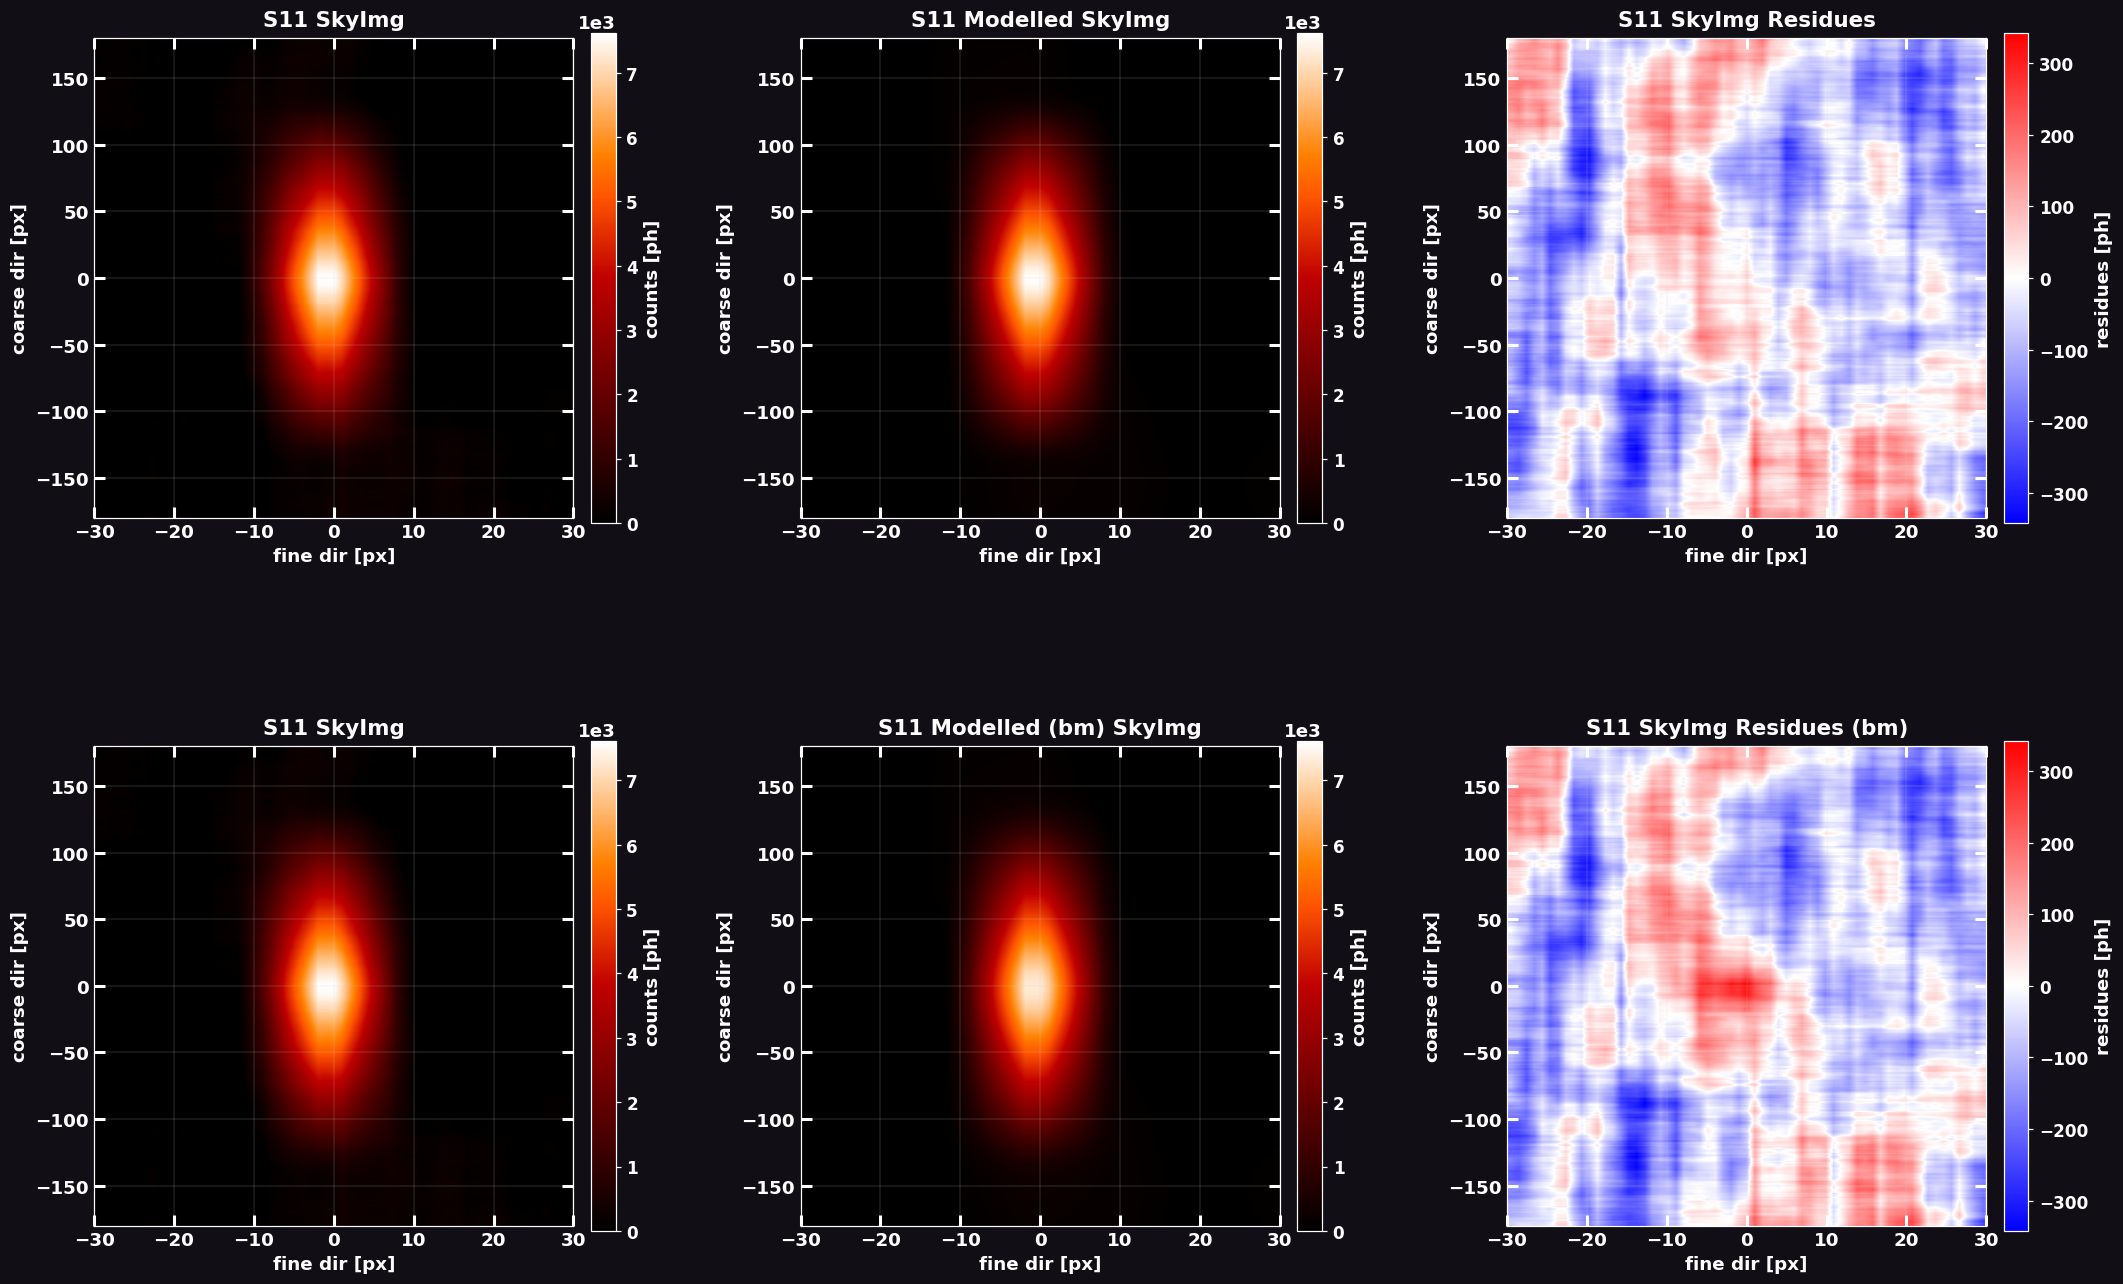

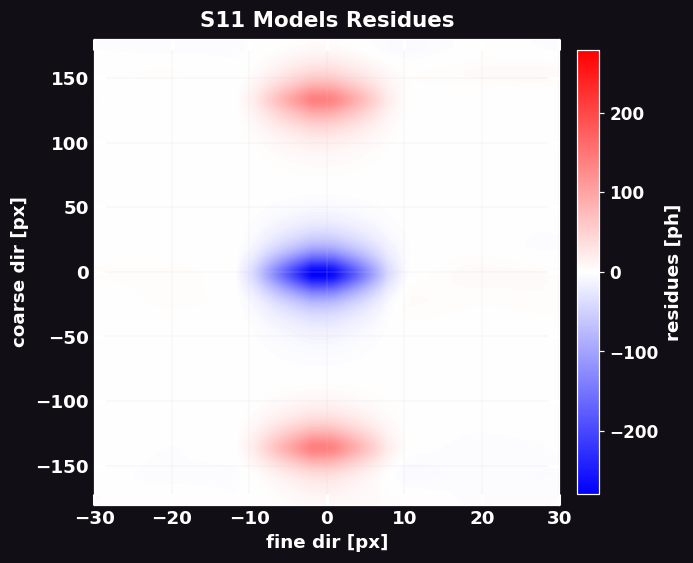

In [15]:
# Sky Images Plots
pos = argmax(sky_reconstructed)
offset = (
    5 * wfm.upscale_f.y,
    2 * wfm.upscale_f.x,
)
_fine, _coarse = ds.psf_extension(wfm)
crp = (
    _coarse + offset[0], _fine + offset[1],
)


skycrp, modelcrp, bm_modelcrp = map(
    lambda x: ds.crop(x, pos, crp), (sky_reconstructed, skymodel, bm_model),
)

_labels: dict = {
    'xlabel': 'fine dir [px]',
    'ylabel': 'coarse dir [px]',
    'cbarlabel': 'counts [ph]',
}
_imgkwargs: dict = {
    'aspect': crp[1] / crp[0],
    'extent': [-crp[1], crp[1], -crp[0], crp[0]],
    'vmin': 0.0,
    'vmax': skycrp.max(),
    'cmap': 'gist_heat',
    'interpolation': 'bilinear',
}
res = skycrp - modelcrp
vlim = np.max(np.abs(res))

sky_dmaps = (
    ds.map4image(
        img=skycrp,
        title=f'{sourceID.upper()} SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=modelcrp,
        title=f'{sourceID.upper()} Modelled SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=res,
        title=f'{sourceID.upper()} SkyImg Residues',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

bm_res = skycrp - bm_modelcrp
bm_dmaps = (
    ds.map4image(
        img=skycrp,
        title=f'{sourceID.upper()} SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=bm_modelcrp,
        title=f'{sourceID.upper()} Modelled (bm) SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=bm_res,
        title=f'{sourceID.upper()} SkyImg Residues (bm)',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

ds.image_plot(
    dmaps=(*sky_dmaps, *bm_dmaps),
    ncols=3,
    nrows=2,
)

models_res = res - bm_res
vlim = np.max(np.abs(models_res))
ds.image_plot(
    ds.map4image(
        img=models_res,
        title=f'{sourceID.upper()} Models Residues',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

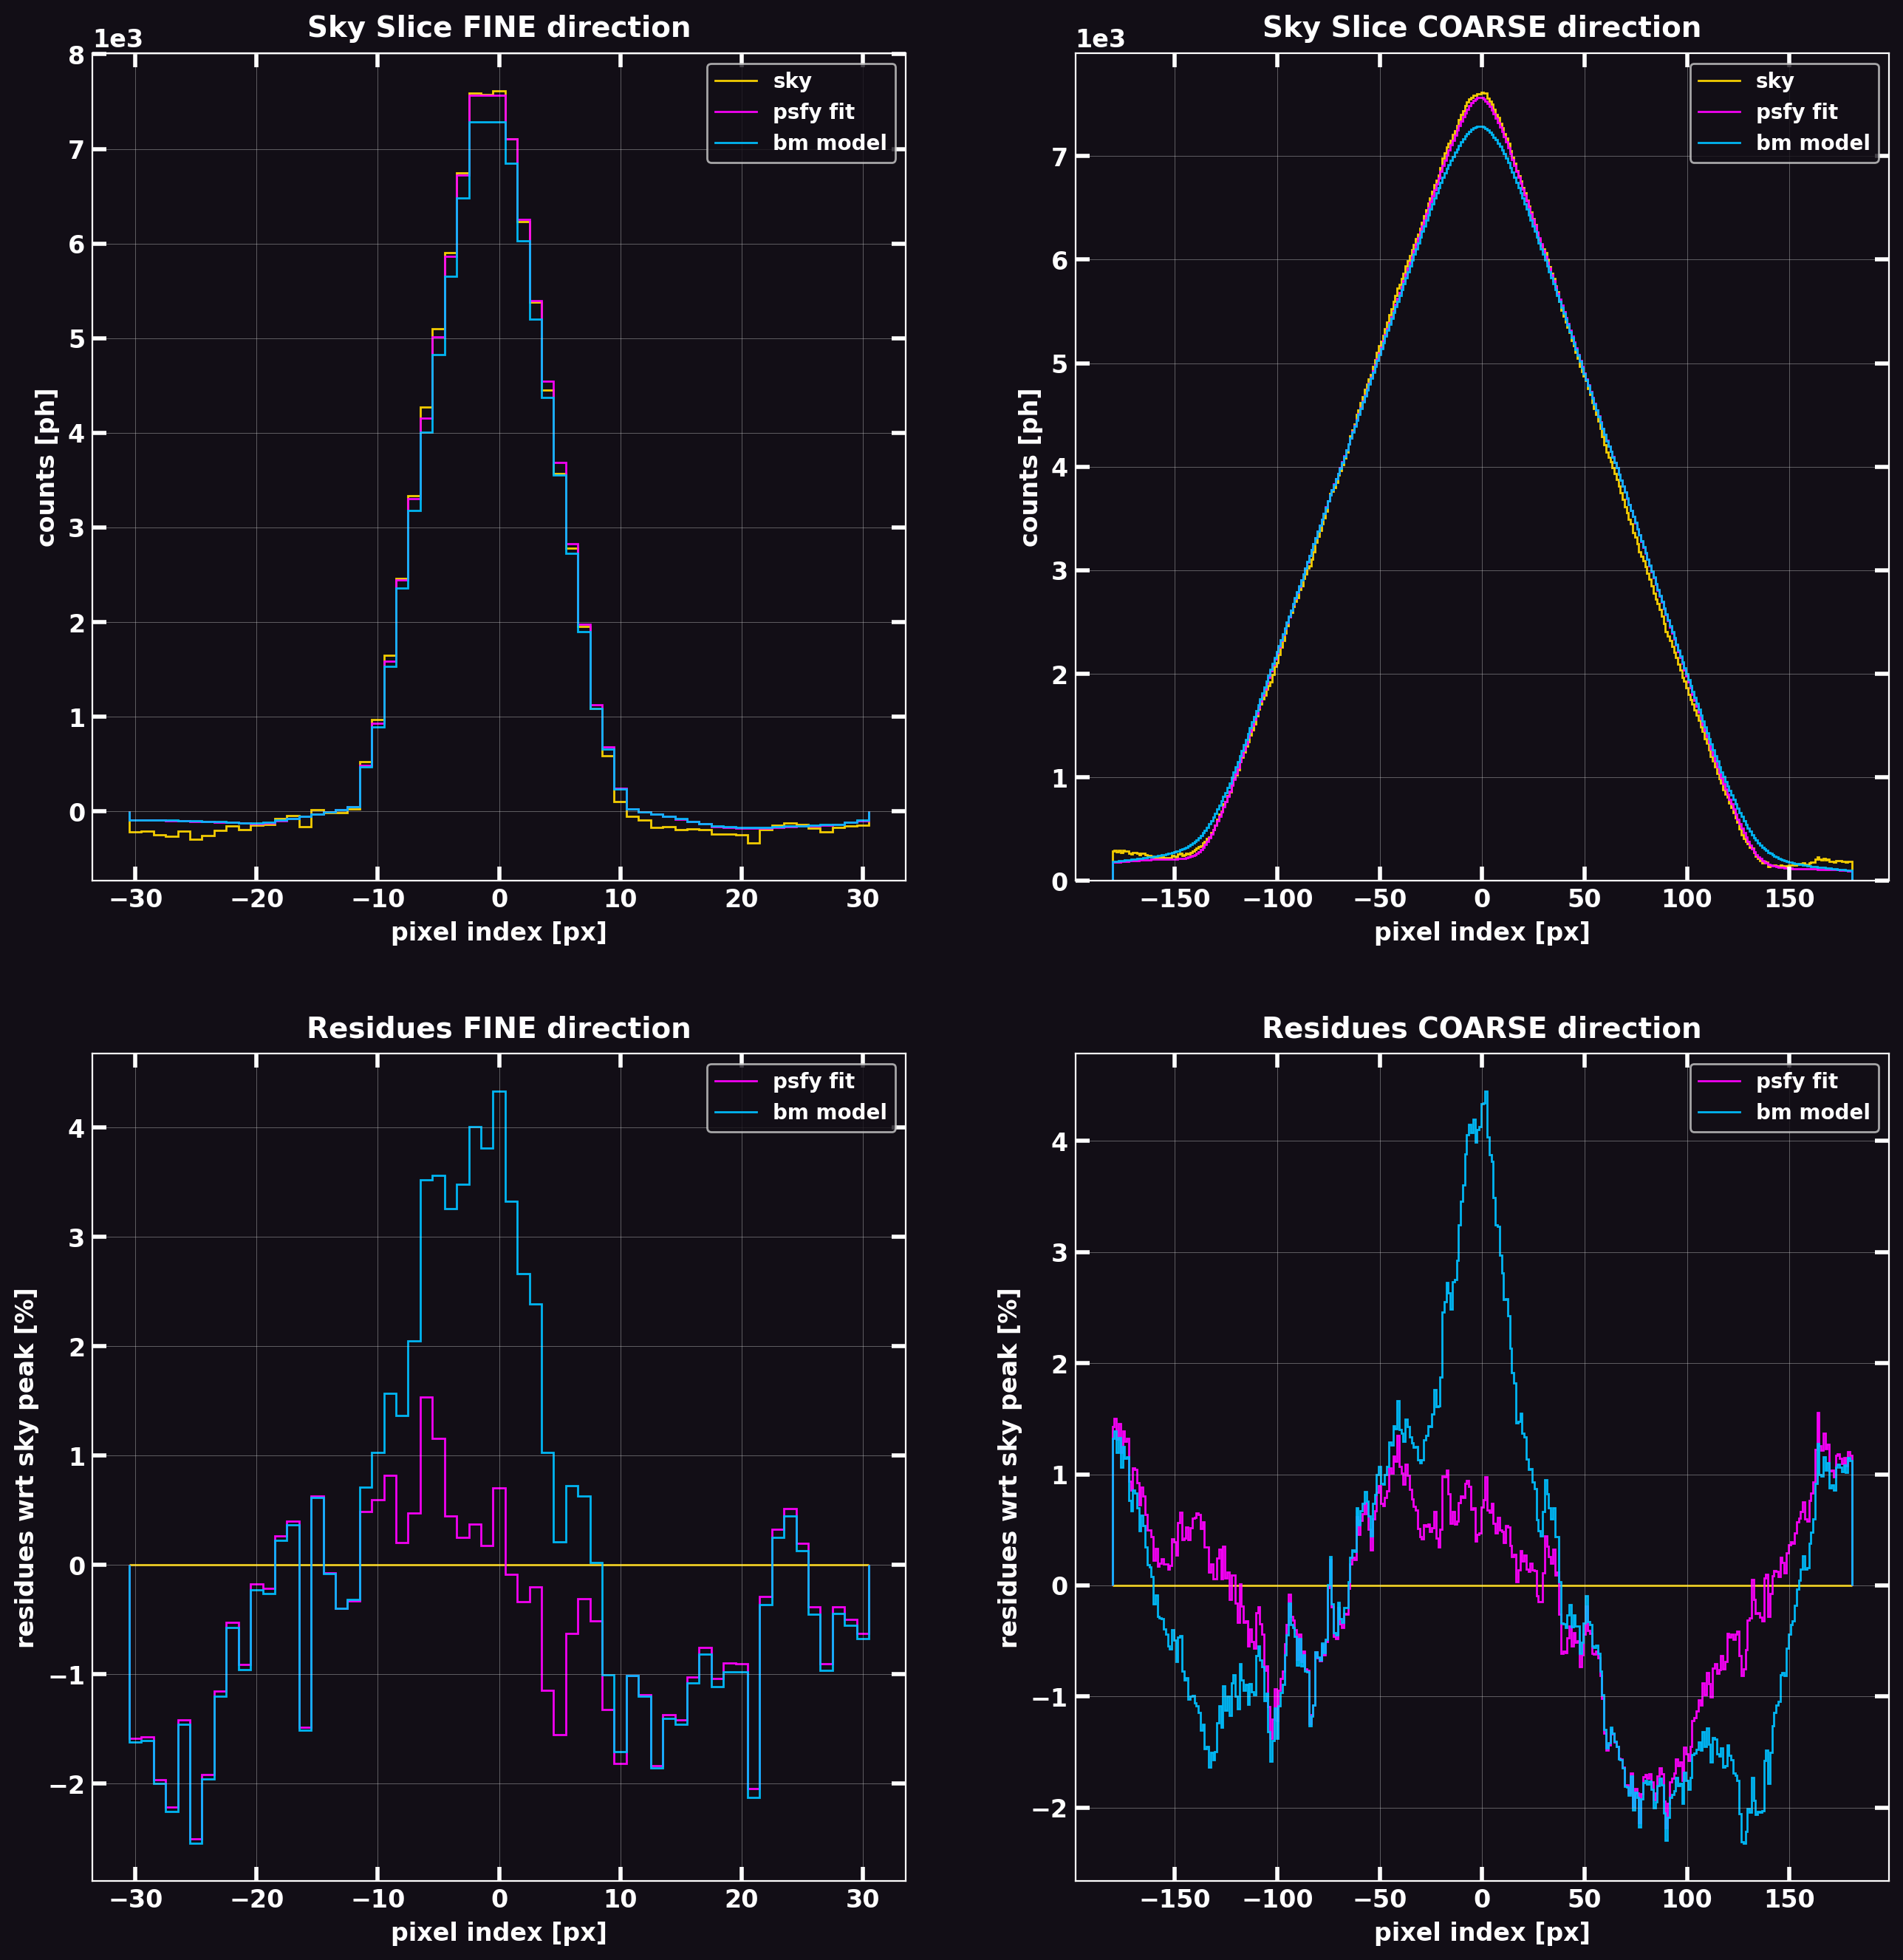

In [17]:
# Profiles Plots
def extract_profile(arr: NDArray, pos: tuple[int, int] | None = None) -> NDArray:
    """Extracts the profile of the input array at given pos."""
    i, j = (
        pos if pos is not None
        else tuple((s - 1) // 2 for s in arr.shape)
    )
    return arr[i, :], arr[:, j]


SHOW_PERC_RES: bool = True


arrs = (skycrp, modelcrp, bm_modelcrp)
clps_x, clps_y = zip(
    *tuple(extract_profile(arr) for arr in arrs)
)

res_, bm_res_ = (
    map(lambda x: x * 100 / skycrp.max(), (res, bm_res)) if SHOW_PERC_RES
    else (res, bm_res)
)
res_arrs = (np.zeros_like(res), res_, bm_res_)
res_clps_x, res_clps_y = zip(
    *tuple(extract_profile(arr) for arr in res_arrs)
)

_get_phase: Callable[[NDArray], NDArray] = lambda x: np.arange(len(x) + 1) - len(x) // 2 - 0.5
_labels: dict = {
    'xlabel': 'pixel index [px]',
    'ylabel': 'counts [ph]',
    'labels': ('sky', 'psfy fit', 'bm model'),
    'color': ('Gold', 'Fuchsia', 'DeepSkyBlue'),
    'style': 'stairs',
}
dmap_clps_x = ds.map4plot(
    arrs=clps_x,
    title='Sky Slice FINE direction',
    x=_get_phase(clps_x[0]),
    **_labels,
)
dmap_clps_y = ds.map4plot(
    arrs=clps_y,
    title='Sky Slice COARSE direction',
    x=_get_phase(clps_y[0]),
    **_labels,
)

_labels['labels'] = ('', 'psfy fit', 'bm model')
if SHOW_PERC_RES:
    _labels['ylabel'] = ('residues wrt sky peak [%]')
res_dmap_clps_x = ds.map4plot(
    arrs=res_clps_x,
    title='Residues FINE direction',
    x=_get_phase(clps_x[0]),
    **_labels,
)
res_dmap_clps_y = ds.map4plot(
    arrs=res_clps_y,
    title='Residues COARSE direction',
    x=_get_phase(clps_y[0]),
    **_labels,
)
ds.plot(
    dmaps=(
        dmap_clps_x, dmap_clps_y,
        res_dmap_clps_x, res_dmap_clps_y,
    ),
    ncols=2,
    nrows=2,
)